In [2]:
import requests 
import numpy as np 
import pandas as pd 
import torch 
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import platform

In [3]:
if platform.system() =='Darwin':
    plt.rc('font', family = 'AppleGothic')
else:
    plt.rc('font', family = 'Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

In [4]:
# 데이터 수집 (openapi)
url = "https://api.thingspeak.com/channels/12397/feeds.json?results=500"
res = requests.get(url)
data = res.json()
data

{'channel': {'id': 12397,
  'name': 'WeatherStation',
  'description': 'MathWorks Weather Station, West Garage, Natick, MA 01760, USA',
  'latitude': '42.299676',
  'longitude': '-71.350525',
  'field1': 'Wind Direction (North = 0 degrees)',
  'field2': 'Wind Speed (mph)',
  'field3': '% Humidity',
  'field4': 'Temperature (F)',
  'field5': 'Rain (Inches/minute)',
  'field6': 'Pressure ("Hg)',
  'field7': 'Power Level (V)',
  'field8': 'Light Intensity',
  'created_at': '2014-05-20T21:50:32Z',
  'updated_at': '2025-10-02T21:56:57Z',
  'elevation': '60',
  'last_entry_id': 5605592},
 'feeds': [{'created_at': '2026-05-26T13:02:38Z',
   'entry_id': 5605093,
   'field1': '186',
   'field2': '3.8',
   'field3': '0',
   'field4': '0.1',
   'field5': '0',
   'field6': '29.88',
   'field7': '0',
   'field8': '0'},
  {'created_at': '2026-05-26T13:03:38Z',
   'entry_id': 5605094,
   'field1': '180',
   'field2': '1.1',
   'field3': '0',
   'field4': '0.1',
   'field5': '0',
   'field6': '29.88',

- field1 : 풍향 -> 도 단위 (0 ~ 360)
- field2 : 풍속 -> m/s
- field3 : 상대 습도 -> %
- field4 : 기온 -> 화씨 단위
- field5 : 강우량 -> mm
- field6 : 기압 -> hPa
- field7 : 조도/일사량 -> 빛의 세기 
- field8 : 센서 베터리의 전압 -> 장비 전원 상태(V)

In [5]:
df = pd.DataFrame(data['feeds'])
df.head(10)

,created_at,entry_id,field1,field2,field3,field4,field5,field6,field7,field8
0,2026-05-26T13:02:38Z,5605093,186,3.8,0,0.1,0,29.88,0,0
1,2026-05-26T13:03:38Z,5605094,180,1.1,0,0.1,0,29.88,0,0
2,2026-05-26T13:04:38Z,5605095,180,3.4,0,0.1,0,29.88,0,0
3,2026-05-26T13:06:38Z,5605096,167,6.6,0,0.1,0,29.88,0,0
4,2026-05-26T13:07:38Z,5605097,175,2.6,0,0.1,0,29.88,0,0
5,2026-05-26T13:08:38Z,5605098,178,3.2,0,0.1,0,29.88,0,0
6,2026-05-26T13:09:38Z,5605099,173,4.5,0,0.1,0,29.88,0,0
7,2026-05-26T13:10:38Z,5605100,177,6,0,0.1,0,29.88,0,0
8,2026-05-26T13:11:38Z,5605101,172,6,0,0.1,0,29.88,0,0
9,2026-05-26T13:12:38Z,5605102,177,5.6,0,0.1,0,29.88,0,0


In [6]:
df = df[['created_at', 'field2']]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   created_at  500 non-null    object
 1   field2      500 non-null    object
dtypes: object(2)
memory usage: 7.9+ KB


In [7]:
df.columns = ['Time', 'value']

In [8]:
df.describe()

,Time,value
count,500,500
unique,500,86
top,2026-05-26T13:02:38Z,4.8
freq,1,16


In [ ]:
df['value'] = pd.to_numeric(df['value'])

In [10]:
df.describe()

,value
count,500.000000
mean,4.137200
std,2.084828
min,0.100000
25%,2.400000
50%,4.200000
75%,5.700000
max,11.500000


In [12]:
# 정규화 -> 스케일링 
scaler = MinMaxScaler()
df['scaled_value'] = scaler.fit_transform(df[['value']])
df.head()

,Time,value,scaled_value
0,2026-05-26T13:02:38Z,3.8,0.324561
1,2026-05-26T13:03:38Z,1.1,0.087719
2,2026-05-26T13:04:38Z,3.4,0.289474
3,2026-05-26T13:06:38Z,6.6,0.570175
4,2026-05-26T13:07:38Z,2.6,0.219298


In [ ]:
features = df[['scaled_value']].values
features

In [14]:
class windowDS(Dataset):
    def __init__(self, _x , _window):
        self.data = _x
        self.window = _window
        self.n = len(_x) - _window
    def __len__(self):
        return self.n
    def __getitem__(self, idx):
        x = self.data[idx : idx + self.window]
        y = self.data[idx + self.window]
        x_tensor = torch.from_numpy(x).float()
        y_tensor = torch.tensor(y).float()
        return x_tensor, y_tensor


In [16]:
sensor_ds = windowDS(features, 10)

train_dl = DataLoader(sensor_ds, batch_size=32, shuffle=False)

In [17]:
class SensorLSTM(nn.Module):
    def __init__(
            self, 
            input_size , 
            hidden_size
    ):
        super(SensorLSTM, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            batch_first=True
        )
        self.model = nn.Linear(hidden_size, 1)
    
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        pred = self.model(h_n[-1])
        return pred

In [18]:
model = SensorLSTM(1, 16)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr = 0.01)


In [19]:
model.train()
for epoch in range(30):
    total_loss = 0.0
    total_n = 0
    for x, y in train_dl:
        pred = model(x)
        loss = criterion(pred, y)
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * y.size(0)
        total_n = y.size(0)
    train_loss = total_loss / max(total_n, 1)

    if (epoch+1) % 5 == 0:
        print(f"Epoch : {epoch+1}, MSE : {train_loss}")

Epoch : 5, MSE : 1.4193131301552058
Epoch : 10, MSE : 0.8310255885124207
Epoch : 15, MSE : 0.8171136926859617
Epoch : 20, MSE : 0.8144017703831196
Epoch : 25, MSE : 0.8057235844433308
Epoch : 30, MSE : 0.7963295854628086


In [35]:
# 예측 값 -> 기존의 데이터를 이용해서 예측 ( 원본의 데이터 모두를 예측 ) 
model.eval()

full_loader = DataLoader( sensor_ds, batch_size=len(sensor_ds), shuffle=False )
# for x, y in full_loader:
    # pass
# next(iter(DataLoader)) : 생성된 데이터들중 첫번째 데이터셋을 로드한다. 
x, y = next(iter(full_loader))

with torch.no_grad():
    pred = model(x)
    errors = torch.abs(y - pred).numpy()

# 오차의 분포에서 상위 5% 지점을 이상치 임계값 설정 
threshold = np.percentile(errors, 90)
anomalies = errors > threshold

In [36]:
print("임계 지점의 값 :", round(threshold, 4))

임계 지점의 값 : 0.2178


In [37]:
anomalies

array([[ True],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [

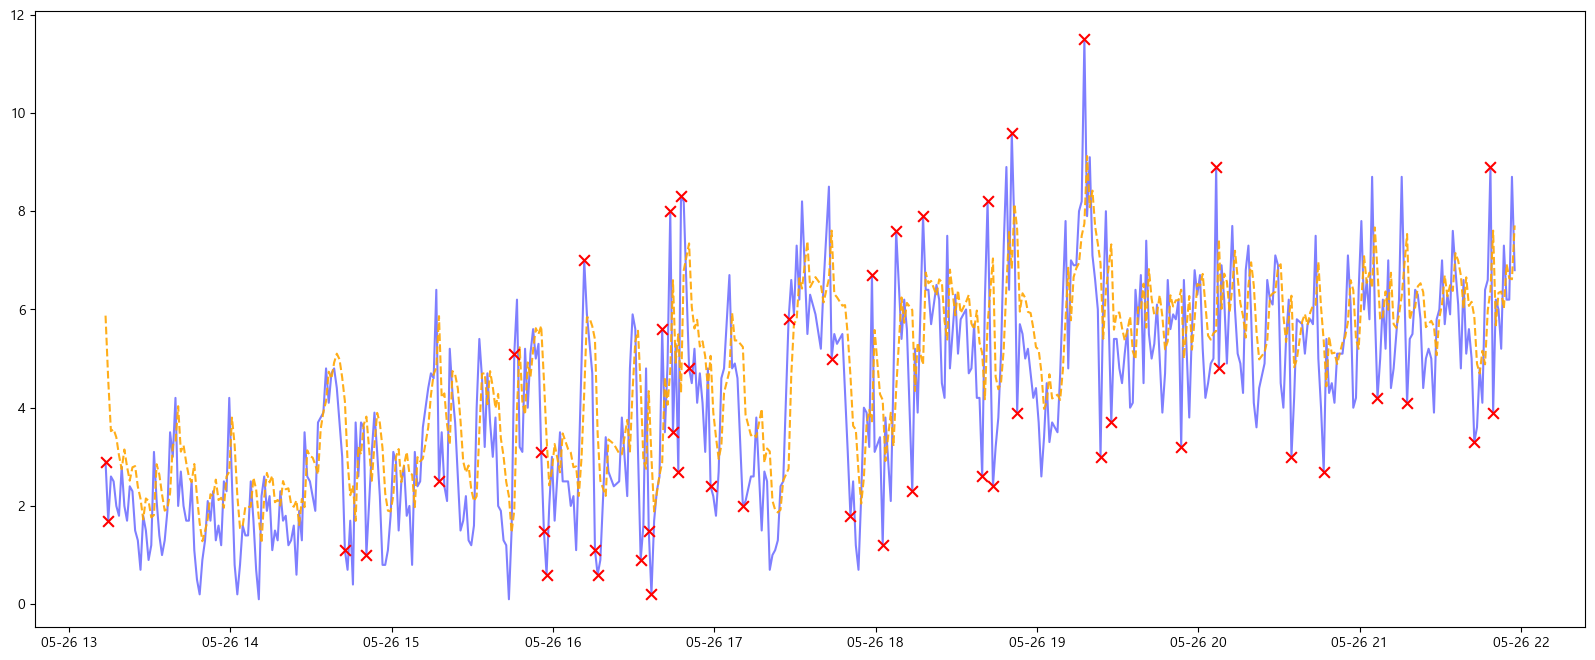

In [38]:
true_y = scaler.inverse_transform(y)
pred_y = scaler.inverse_transform(pred)
df['Time'] = pd.to_datetime(df['Time'])
plot_x = df['Time'].iloc[10:].values

plt.figure(figsize=(20, 8))

plt.plot(plot_x, true_y, label = '실제 센서 데이터', color = 'blue', alpha = 0.5)
plt.plot(plot_x, pred_y, label = '예측 센서 데이터', color = 'orange', 
         alpha = 0.9, linestyle = '--')

# 이상치가 감지된 인덱스를 추출하고 산점도 그래프를 추가하여 이상치를 표시 
anomaly_idx = np.where(anomalies)[0]
if len(anomaly_idx) > 0:
    plt.scatter(
        plot_x[anomaly_idx], true_y[anomaly_idx], 
        color = 'red', label = '이상 징후 감지', 
        s = 60, marker = 'x', zorder=5
    )

plt.show()